In [36]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = 7
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_for_cache_list_threshold"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [37]:
# Only record build and update in dynamic

library_size = 1_000_000

ion_mode = [1, -1]

added_size=1_000_000
cache_list_threshold=[1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000]


In [38]:
import matplotlib.ticker as ticker

df=[]
for threshold in cache_list_threshold:
    data={"cache_list_threshold":threshold, "number_of_spectra_per_file":1000000, "number_of_files":100}
    for charge in ion_mode:
        path_benchmark_specific_data_dynamic=path_benchmark_data/f"dynamic_fast_update_{charge}_memory_usage_options_{threshold}_cache_list_threshold.txt"
        
        with open(path_benchmark_specific_data_dynamic,"r") as f1:
            for line in f1.readlines():
                items=line.split(":", maxsplit=1)
                key, value=items
                if key.strip()=="Maximum resident set size (kbytes)":
                    dynamic=int(value.strip())

        data["dynamic_entropy_search(fast_update)"]=dynamic/1048576
        data["charge"]=charge
        
        df.append(pd.DataFrame([data]))
    
df=pd.concat(df)
df

,cache_list_threshold,number_of_spectra_per_file,number_of_files,dynamic_entropy_search(fast_update),charge
0,1000,1000000,100,0.316189,1
0,1000,1000000,100,0.206486,-1
0,5000,1000000,100,0.225254,1
0,5000,1000000,100,0.300556,-1
0,10000,1000000,100,0.389885,1
0,10000,1000000,100,0.271805,-1
0,50000,1000000,100,0.654243,1
0,50000,1000000,100,0.409916,-1
0,100000,1000000,100,1.168007,1
0,100000,1000000,100,0.760715,-1


In [39]:

df_data = df[["cache_list_threshold", 
              "charge",
            "dynamic_entropy_search(fast_update)", 
]]

df_melted=df_data.melt(id_vars=["charge", "cache_list_threshold"], var_name="type", value_name="memory_usage")
df_melted

,charge,cache_list_threshold,type,memory_usage
0,1,1000,dynamic_entropy_search(fast_update),0.316189
1,-1,1000,dynamic_entropy_search(fast_update),0.206486
2,1,5000,dynamic_entropy_search(fast_update),0.225254
3,-1,5000,dynamic_entropy_search(fast_update),0.300556
4,1,10000,dynamic_entropy_search(fast_update),0.389885
5,-1,10000,dynamic_entropy_search(fast_update),0.271805
6,1,50000,dynamic_entropy_search(fast_update),0.654243
7,-1,50000,dynamic_entropy_search(fast_update),0.409916
8,1,100000,dynamic_entropy_search(fast_update),1.168007
9,-1,100000,dynamic_entropy_search(fast_update),0.760715


In [40]:
def plot_memory_options_cache_list_threshold(
    df,
    color_palette,
    ylim,
    save_path
):
    # df_charge=df_melted[df_melted["charge"]==charge]
    fig, ax = plt.subplots(figsize=(3, 2))

    sns.barplot(x="cache_list_threshold", y="dynamic_entropy_search(fast_update)", hue="charge", data=df, palette=color_palette,
                legend=True, width=0.5, errwidth=0)

    bottom=ylim[0]
    top=ylim[1]
    plt.ylim(top=top, bottom=bottom)
    plt.ylabel(f"Index Build Memory Usage (GB)")
    plt.xlabel(f"Cache size")

    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    ax.tick_params(axis='both', 
               which='both',
               width=0.4,
               )    
    current_labels = [int(label.get_text()) for label in ax.get_xticklabels()]
    new_labels = [f"{label:,}" for label in current_labels]
    ax.set_xticklabels(new_labels)
    plt.xticks(rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ['(+)ESI' if label == '1' else '(-)ESI' for label in labels]
    ax.legend(handles, custom_labels,loc='upper center',bbox_to_anchor=(0.5,1.2), framealpha=0.9, ncol=2,frameon=False, )
    plt.savefig(save_path, bbox_inches="tight", dpi=1200)

In [41]:
# color_palette={
#     1: '#ca3032',
#     -1:"#32586d"
# }
# my_color_palette=sns.color_palette("tab20c", 20)
color_palette={
    1: '#FCD470',
    -1:'#66BC98'
}

/tmp/ipykernel_22838/1171485789.py:10: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x="cache_list_threshold", y="dynamic_entropy_search(fast_update)", hue="charge", data=df, palette=color_palette,
/tmp/ipykernel_22838/1171485789.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


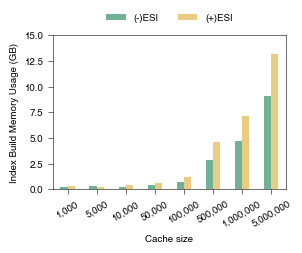

In [42]:
# charge=-1
ylim=(0,15)
save_path=path_figures / f"memory_usage_options_cache_list_threshold.svg"
plot_memory_options_cache_list_threshold(
    df=df,
    ylim=ylim,
    color_palette=color_palette,
    save_path=save_path
)